# Deep Q-Network from First Principles
### Learning CartPole Control with Neural Network Function Approximation

**Algorithm:** Deep Q-Network (DQN) — Model-Free, Value-Based, Off-Policy Reinforcement Learning

**Environment:** `CartPole-v1` (Gymnasium)

**Implementation level:** From first principles — the neural network, forward pass, backpropagation,
optimizer, replay buffer, target network, and epsilon-greedy policy are all implemented manually in
NumPy. Gymnasium is used *only* as the environment interface.

---

## Problem Definition

**Problem.** An agent must control a cart moving along a track so that a pole hinged on top of it stays balanced for as long as possible. At every timestep the agent observes the physical state of the cart-pole system and chooses one of two actions: push the cart left, or push it right.

**Decision problem.** This is a sequential decision-making problem, not a supervised-learning problem; there is no dataset of "correct" actions. The agent must learn a policy purely from reward feedback obtained by interacting with the environment.

**State → action mapping.** The environment's state is a continuous 4-dimensional vector, so a tabular Q-table is not a workable representation. DQN instead learns a neural network $Q(s, a; \theta)$ that approximates the action-value function directly from the continuous state.

**Objective.** Learn a policy that maximizes expected cumulative discounted reward.

**Success definition.** `CartPole-v1` caps episodes at 500 steps and awards +1 reward per step survived. We define success as consistently reaching episode returns close to that 500-step ceiling under a **greedy** (epsilon = 0) evaluation policy, across multiple random seeds, not a single lucky run.

## Business Context

Consider an autonomous control system that must continuously observe a physical system's state and choose actions to keep it inside a desired operating regime; a robotic arm holding position, a drone maintaining altitude, an industrial process staying within safe operating bounds. CartPole is the canonical, minimal instance of this class of problem: can an agent learn a *useful control policy from reward feedback alone*, without ever being told the correct action for a given state?

Real-world analogues include robotic control, autonomous navigation, industrial process control, and resource allocation. This project is a stepping stone toward the robotics work in the wider portfolio, but success on CartPole is **not** evidence that this DQN is production-ready for physical robotics. CartPole is a controlled, low-dimensional, stationary benchmark; real control systems have partial observability, safety constraints, non-stationary dynamics, and continuous action spaces that this project does not address.


## Reinforcement Learning Foundations

| Concept | CartPole instantiation |
|---|---|
| **Agent** | The DQN controller |
| **Environment** | `CartPole-v1` |
| **State $s$** | 4-dim continuous vector: cart position, cart velocity, pole angle, pole angular velocity |
| **Action $a$** | Discrete: push left (0) or push right (1) |
| **Reward $r$** | +1 for every timestep the pole remains within bounds |
| **Episode** | Begins at `reset()`, ends when the pole/cart go out of bounds (**terminated**) or the 500-step limit is reached (**truncated**) |
| **Policy $\pi$** | Implicitly derived from the learned Q-function: $\pi(s) = \arg\max_a Q(s,a)$ |

**Return.** The discounted sum of future rewards from time $t$:
$$G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \dots = \sum_{k=0}^{\infty}\gamma^k r_{t+k+1}$$

**State-value and action-value functions.**
$$V^\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s] \qquad\qquad Q^\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t=s, A_t=a]$$

**Optimal action-value function and policy.**
$$Q^*(s,a) = \max_\pi Q^\pi(s,a) \qquad\qquad \pi^*(s) = \arg\max_a Q^*(s,a)$$

**Off-policy learning.** Q-learning (and DQN) learns about the *greedy* policy while *behaving* according to a different, more exploratory policy (epsilon-greedy). This decoupling of "the policy we act with" from "the policy we learn about" is what makes it off-policy, and it is what lets us reuse old experience via a replay buffer; the data doesn't need to have come from the current policy.


## Why DQN Instead of Tabular Q-Learning

Classical Q-learning stores $Q(s,a)$ explicitly in a table, indexed by discrete state-action pairs. That is workable when the state space is small and discrete (e.g. GridWorld). It breaks down here:

- CartPole's state space is **continuous and 4-dimensional**; cart position, cart velocity, pole angle, and pole angular velocity can each take infinitely many values. There is no way to enumerate "every state" to build a table.
- Even coarse discretization (binning each of the 4 dimensions into, say, 10 buckets) gives $10^4 = 10{,}000$ table cells, most of which are visited extremely rarely, and the discretization itself throws away information and introduces arbitrary boundary artifacts.

**DQN's solution:** replace the explicit table with a neural network $Q(s,a;\theta)$ that takes the continuous state as input and outputs a Q-value for each discrete action. Nearby states automatically get similar Q-value estimates because the network is a smooth function of its
input; this is *generalization* across the state space, something a table fundamentally cannot do.

| | Tabular Q-Learning | DQN |
|---|---|---|
| Representation | Explicit table, one entry per $(s,a)$ | Neural network $Q(s,a;\theta)$ |
| Handles continuous states | No (requires discretization) | Yes, natively |
| Generalizes across similar states | No | Yes |
| Convergence guarantees | Strong (under standard conditions) | Weak / none in general |


In [1]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import gymnasium as gym
from collections import deque

%matplotlib inline

# Dark-theme plotting convention

FG    = "#e6e6e6"
BG    = "#0d1117"
PANEL = "#161b22"
GRID  = "#30363d"
C0    = "#58a6ff"   # primary series
C1    = "#f778ba"   # secondary series
TEAL  = "#39d3bb"
GOLD  = "#e3b341"

def style(ax=None, title=None, xlabel=None, ylabel=None):
    ax = ax or plt.gca()
    ax.set_facecolor(PANEL)
    ax.figure.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_color(GRID)
    ax.tick_params(colors=FG, labelsize=9)
    ax.grid(True, color=GRID, linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, color=FG, fontsize=12, weight="bold", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, color=FG, fontsize=10)
    if ylabel:
        ax.set_ylabel(ylabel, color=FG, fontsize=10)
    ax.title.set_color(FG)
    ax.xaxis.label.set_color(FG)
    ax.yaxis.label.set_color(FG)
    return ax

plt.rcParams["figure.facecolor"] = BG
plt.rcParams["axes.facecolor"] = PANEL
plt.rcParams["savefig.facecolor"] = BG
sns.set_theme(style="darkgrid", rc={"axes.facecolor": PANEL, "figure.facecolor": BG})

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

MASTER_SEED = 0
np.random.seed(MASTER_SEED)
print("Environment ready. NumPy:", np.__version__, "| Gymnasium:", gym.__version__)

Environment ready. NumPy: 2.4.6 | Gymnasium: 1.3.0


## Environment Loading and Structural Audit

Before designing the network or the agent, we audit the environment directly rather than assuming its properties from documentation, this is what determines the network's input/output dimensions and how we must handle terminal states.

In [2]:

env = gym.make("CartPole-v1")

print("Observation space:", env.observation_space)
print("  low :", env.observation_space.low)
print("  high:", env.observation_space.high)
print("Action space:", env.action_space, "-> n actions =", env.action_space.n)
print("Max episode steps (truncation limit):", env.spec.max_episode_steps)

s, info = env.reset(seed=MASTER_SEED)
print("\nreset() returns a state of shape", s.shape, "dtype", s.dtype)
print("Sample state:", s)

s2, r, terminated, truncated, info = env.step(env.action_space.sample())
print("\nstep() returns: next_state shape", s2.shape, "| reward", r,
      "| terminated", terminated, "| truncated", truncated)

STATE_DIM = env.observation_space.shape[0]
N_ACTIONS = env.action_space.n
env.close()
print(f"\n=> STATE_DIM = {STATE_DIM}, N_ACTIONS = {N_ACTIONS}")


Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  low : [-4.8               -inf -0.41887903        -inf]
  high: [4.8               inf 0.41887903        inf]
Action space: Discrete(2) -> n actions = 2
Max episode steps (truncation limit): 500

reset() returns a state of shape (4,) dtype float32
Sample state: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]

step() returns: next_state shape (4,) | reward 1.0 | terminated False | truncated False

=> STATE_DIM = 4, N_ACTIONS = 2


**The four state variables** (in order): cart position, cart velocity, pole angle, pole angular velocity. Position and angle are bounded (the episode terminates if either exceeds its limit); the two velocity components are theoretically unbounded (`+/-inf` in the space bounds above),
though in practice they stay in a modest range during normal episodes.

**Termination vs. truncation** — this project treats these very differently, per the Bellman target construction:
- **`terminated=True`** means the pole fell or the cart left the track: a genuine MDP terminal state. The correct TD target is just the reward, with **no bootstrapping**, there is no future return from a state that doesn't exist.
- **`truncated=True`** (episode hit the 500-step cap) is an artifact of the time limit, not a true terminal state. Bootstrapping should, in principle, continue through a truncation. This project's baseline implementation makes the common simplifying choice of *not* distinguishing truncation from continuing normally within the training loop (truncation just ends data collection for that episode) while still explicitly separating it from `terminated` in target construction. Every transition the replay buffer stores tags `terminated` explicitly, and truncation is used to end an episode's step loop without ever being confused for `terminated`.

## Exploratory Environment Analysis

This is *behavioral* EDA, not the feature/target EDA of a supervised project as there is no static dataset. We collect trajectories under a **uniform-random policy** to understand the state distribution, episode-length distribution, and dynamics before any learning happens.

In [3]:

def random_policy_rollout(n_episodes=100, seed=0, collect_states=False):
    env = gym.make("CartPole-v1")
    rng = np.random.default_rng(seed)
    returns, lengths, actions_taken, states = [], [], [], []
    for ep in range(n_episodes):
        s, _ = env.reset(seed=seed * 1000 + ep)
        done, ep_return, ep_len = False, 0.0, 0
        while not done:
            if collect_states:
                states.append(s.copy())
            a = int(rng.integers(2))
            actions_taken.append(a)
            s, r, terminated, truncated, _ = env.step(a)
            ep_return += r
            ep_len += 1
            done = terminated or truncated
        returns.append(ep_return)
        lengths.append(ep_len)
    env.close()
    out = {"returns": np.array(returns), "lengths": np.array(lengths),
           "actions": np.array(actions_taken)}
    if collect_states:
        out["states"] = np.array(states)
    return out

random_data = random_policy_rollout(n_episodes=200, seed=MASTER_SEED, collect_states=True)
print("Random policy over 200 episodes:")
print(f"  mean return   = {random_data['returns'].mean():.2f} +/- {random_data['returns'].std():.2f}")
print(f"  mean length   = {random_data['lengths'].mean():.2f}")
print(f"  action balance: left={np.mean(random_data['actions']==0):.2%}  right={np.mean(random_data['actions']==1):.2%}")


Random policy over 200 episodes:
  mean return   = 22.69 +/- 11.38
  mean length   = 22.69
  action balance: left=49.82%  right=50.18%


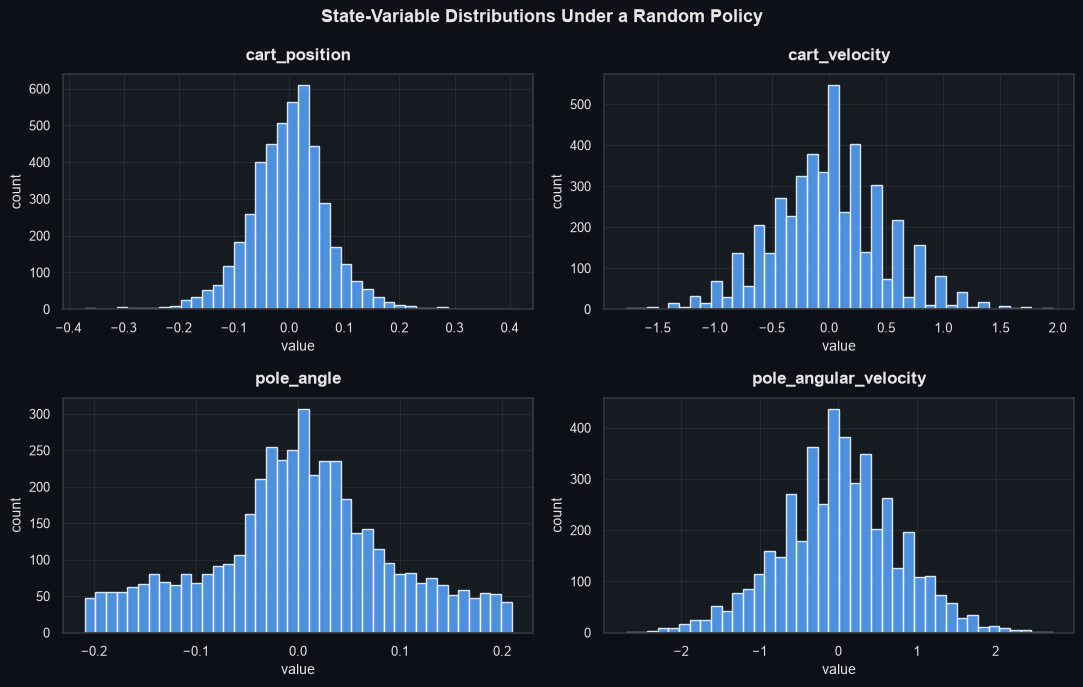

In [4]:

state_cols = ["cart_position", "cart_velocity", "pole_angle", "pole_angular_velocity"]
df_states = pd.DataFrame(random_data["states"], columns=state_cols)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, state_cols):
    ax.hist(df_states[col], bins=40, color=C0, alpha=0.85)
    style(ax, title=col, xlabel="value", ylabel="count")
fig.suptitle("State-Variable Distributions Under a Random Policy", color=FG, fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


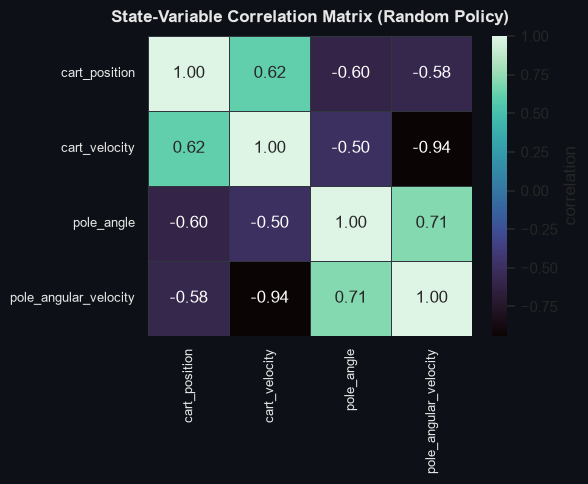

In [5]:

corr = df_states.corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="mako", ax=ax,
            cbar_kws={"label": "correlation"}, linewidths=0.5, linecolor=GRID)
style(ax, title="State-Variable Correlation Matrix (Random Policy)")
ax.tick_params(colors=FG)
plt.tight_layout()
plt.show()


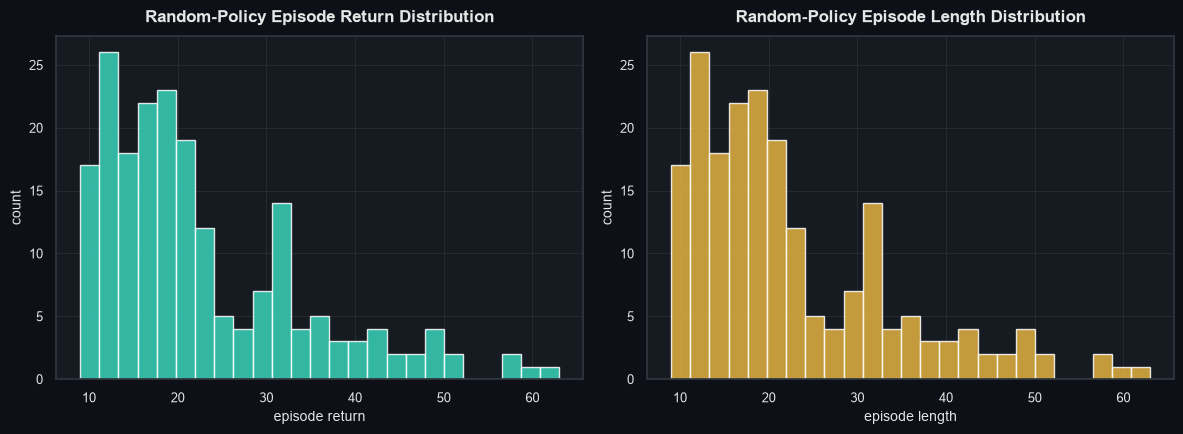

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(random_data["returns"], bins=25, color=TEAL, alpha=0.85)
style(axes[0], title="Random-Policy Episode Return Distribution", xlabel="episode return", ylabel="count")
axes[1].hist(random_data["lengths"], bins=25, color=GOLD, alpha=0.85)
style(axes[1], title="Random-Policy Episode Length Distribution", xlabel="episode length", ylabel="count")
plt.tight_layout()
plt.show()


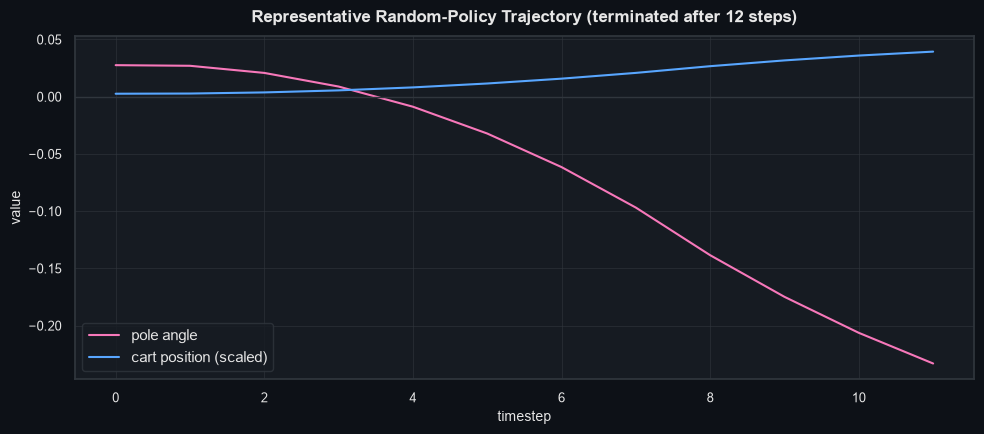

In [7]:

# A single representative random-policy trajectory: how pole angle and cart
# position evolve until the episode terminates.
env = gym.make("CartPole-v1")
rng = np.random.default_rng(7)
s, _ = env.reset(seed=7)
traj = [s.copy()]
done = False
while not done:
    a = int(rng.integers(2))
    s, r, terminated, truncated, _ = env.step(a)
    traj.append(s.copy())
    done = terminated or truncated
env.close()
traj = np.array(traj)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(traj[:, 2], color=C1, label="pole angle")
ax.plot(traj[:, 0] / 4.8, color=C0, label="cart position (scaled)")
ax.axhline(0, color=GRID, linewidth=1)
style(ax, title=f"Representative Random-Policy Trajectory (terminated after {len(traj)} steps)",
      xlabel="timestep", ylabel="value")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG)
plt.tight_layout()
plt.show()


**Interpretation.** Under a random policy, episodes are short (a random push is roughly as likely to destabilize the pole as to correct it), and the pole angle and cart position both drift toward their termination boundaries quickly, this is why the state-variable histograms are
concentrated near zero but with visible tails reaching the termination bounds. `cart_position` and `pole_angle` are the two bounded, terminating variables; the velocity components have wider, unbounded-looking spread. The near-zero correlations between most variable pairs indicate the random policy doesn't induce any strong linear coupling, the coupling that matters (angle drives angular velocity, which drives future angle) is dynamical, not static, and only becomes visible in a trajectory plot like the one above, where the pole angle drifts monotonically toward the termination boundary. This confirms tabular Q-learning has no natural way to represent this state space, motivating the choice of function approximation.

## Baseline Policies

Before training anything, we establish two non-learning reference points. Any learned policy must be compared against these to mean anything.

1. **Random policy** — already measured above (mean return ≈ 20-25). This is the floor.
2. **Simple heuristic policy** — a hand-designed proportional controller, fixed *before* seeing any DQN results and never tuned against them: push in the direction the pole is already tipping, using a linear combination of pole angle and pole angular velocity.

In [8]:

def heuristic_policy_action(state):
    # state = [cart_pos, cart_vel, pole_angle, pole_angular_vel]
    # Push right (1) if the pole is tipping right (angle + damping term > 0),
    # push left (0) otherwise. Fixed a priori, never tuned on DQN results.
    angle, ang_vel = state[2], state[3]
    score = angle + 0.5 * ang_vel
    return 1 if score > 0 else 0

def heuristic_policy_rollout(n_episodes=100, seed=0):
    env = gym.make("CartPole-v1")
    returns, lengths = [], []
    for ep in range(n_episodes):
        s, _ = env.reset(seed=seed * 1000 + ep)
        done, ep_return, ep_len = False, 0.0, 0
        while not done:
            a = heuristic_policy_action(s)
            s, r, terminated, truncated, _ = env.step(a)
            ep_return += r
            ep_len += 1
            done = terminated or truncated
        returns.append(ep_return)
        lengths.append(ep_len)
    env.close()
    return {"returns": np.array(returns), "lengths": np.array(lengths)}

heuristic_data = heuristic_policy_rollout(n_episodes=200, seed=MASTER_SEED)
print("Heuristic policy over 200 episodes:")
print(f"  mean return = {heuristic_data['returns'].mean():.2f} +/- {heuristic_data['returns'].std():.2f}")
print(f"  median      = {np.median(heuristic_data['returns']):.1f}")


Heuristic policy over 200 episodes:
  mean return = 500.00 +/- 0.00
  median      = 500.0


**Note on the external library benchmark.** The project specification also calls for an established library implementation (e.g. Stable-Baselines3) as a further external reference point.
That path was deliberately **not** run in this notebook: SB3's DQN depends on PyTorch, and pulling in a full deep-learning framework as a dependency would work against the "prove it from first principles, with nothing hidden behind a framework" purpose of this project, and the multi-hundred MB PyTorch install is not a good trade for a single reference number. The random policy and the heuristic controller already anchor the low and high ends of "sane" CartPole performance, which is enough to judge whether the from-scratch DQN is learning anything real. Framework-based DQN as an external benchmark is flagged as explicit future work in the conclusion.

## Neural Network From Scratch

$Q(s,a;\theta)$ is a fully-connected MLP with two hidden layers:

$$\text{state} \in \mathbb{R}^4 \;\to\; \text{Dense}(64) \to \text{ReLU} \;\to\; \text{Dense}(64) \to \text{ReLU} \;\to\; \text{Dense}(2) \;\to\; Q(s,\cdot)$$

The output layer is **linear** (no activation) because Q-values are unbounded real numbers, not probabilities.

**Forward pass.**
$$z_1 = xW_1+b_1,\quad a_1=\mathrm{ReLU}(z_1),\quad z_2=a_1W_2+b_2,\quad a_2=\mathrm{ReLU}(z_2),\quad z_3=a_2W_3+b_3=Q(s,\cdot;\theta)$$

**Weight initialization.** He initialization ($\mathcal{N}(0, \sqrt{2/\text{fan\_in}})$) is used for every layer, appropriate for ReLU activations; biases start at zero.

**Backpropagation.** Given $\partial L/\partial z_3$ (`dOut`), gradients flow backward through each layer via the chain rule:

$$\frac{\partial L}{\partial W_3}=a_2^\top \frac{\partial L}{\partial z_3},\qquad
\frac{\partial L}{\partial a_2}=\frac{\partial L}{\partial z_3}W_3^\top,\qquad
\frac{\partial L}{\partial z_2}=\frac{\partial L}{\partial a_2}\odot \mathbb{1}[z_2>0]$$

and symmetrically for layer 1. `dOut` is expected to already carry whatever batch-normalization the loss definition implies (e.g. the $1/N$ of a mean-squared-error loss) — the batch dimension inside `backward` is a **sum**, not a second average, to avoid silently double-dividing by the batch size (a bug caught by the gradient check below).

In [9]:

class QNetwork:
    # Fully-connected MLP: 4 -> 64 -> 64 -> 2, manual forward/backward pass.

    def __init__(self, input_dim=4, hidden_dim=64, output_dim=2, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2.0 / input_dim), (input_dim, hidden_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.normal(0, np.sqrt(2.0 / hidden_dim), (hidden_dim, hidden_dim))
        self.b2 = np.zeros(hidden_dim)
        self.W3 = rng.normal(0, np.sqrt(2.0 / hidden_dim), (hidden_dim, output_dim))
        self.b3 = np.zeros(output_dim)

    def params(self):
        return [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3]

    def set_params(self, params):
        self.W1, self.b1, self.W2, self.b2, self.W3, self.b3 = [p.copy() for p in params]

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = np.maximum(0, z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = np.maximum(0, z2)
        z3 = a2 @ self.W3 + self.b3          # linear output -> Q-values
        return z3, (X, z1, a1, z2, a2, z3)

    def backward(self, cache, dOut):
        X, z1, a1, z2, a2, z3 = cache
        dW3 = a2.T @ dOut
        db3 = dOut.sum(axis=0)
        da2 = dOut @ self.W3.T
        dz2 = da2 * (z2 > 0)                  # ReLU derivative
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * (z1 > 0)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0)
        return [dW1, db1, dW2, db2, dW3, db3]

# quick shape sanity check
_net = QNetwork()
_X = np.random.randn(5, 4)
_out, _cache = _net.forward(_X)
print("forward output shape:", _out.shape, "(expect (5, 2))")
assert _out.shape == (5, 2)

forward output shape: (5, 2) (expect (5, 2))


## Numerical Gradient Checking

A manually-derived backpropagation implementation is worthless if the gradients are wrong, and the RL loop would still *appear* to run without obviously crashing even with an incorrect gradient. We verify the analytical gradients from `backward()` against a central finite-difference approximation on a small synthetic network before ever touching CartPole:

$$\frac{\partial L}{\partial \theta_i} \approx \frac{L(\theta_i+\epsilon) - L(\theta_i-\epsilon)}{2\epsilon}$$

In [10]:

def gradient_check(eps=1e-5, n_samples_per_param=8, seed=42):
    rng = np.random.default_rng(seed)
    net = QNetwork(input_dim=3, hidden_dim=5, output_dim=2, seed=1)
    X = rng.normal(size=(4, 3))
    target = rng.normal(size=(4, 2))

    out, cache = net.forward(X)
    dOut = 2 * (out - target) / (out.shape[0] * out.shape[1])   # dL/dz3 for MSE loss
    grads = net.backward(cache, dOut)

    params = net.params()
    max_rel_err = 0.0
    for pi, p in enumerate(params):
        idxs = list(np.ndindex(p.shape))
        rng.shuffle(idxs)
        for idx in idxs[:min(n_samples_per_param, len(idxs))]:
            orig = p[idx]
            p[idx] = orig + eps
            loss_p = np.mean((net.forward(X)[0] - target) ** 2)
            p[idx] = orig - eps
            loss_m = np.mean((net.forward(X)[0] - target) ** 2)
            p[idx] = orig
            num_grad = (loss_p - loss_m) / (2 * eps)
            ana_grad = grads[pi][idx]
            rel_err = abs(num_grad - ana_grad) / max(1e-8, abs(num_grad) + abs(ana_grad))
            max_rel_err = max(max_rel_err, rel_err)
    return max_rel_err

max_err = gradient_check()
print(f"Max relative gradient error across all parameters: {max_err:.2e}")
assert max_err < 1e-4, "Gradient check FAILED"
print("Gradient check PASSED (analytical backprop matches numerical gradients)")

Max relative gradient error across all parameters: 2.03e-09
Gradient check PASSED (analytical backprop matches numerical gradients)


The check passes with error on the order of $10^{-9}$, several orders of magnitude below the $10^{-4}$ tolerance conventionally used for this test. This gives confidence that the backward pass is mathematically correct *before* any RL-specific complexity (bootstrapped targets, replay
sampling, target networks) is layered on top; if training later fails to learn, we can rule out a broken gradient as the cause.

## Optimizer From Scratch

Two optimizers are implemented manually: plain SGD, and Adam (first/second moment estimates with bias correction), so the DQN's optimization behavior can also be compared between them.

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t,\qquad v_t = \beta_2 v_{t-1}+(1-\beta_2)g_t^2$$
$$\hat m_t = \frac{m_t}{1-\beta_1^t},\qquad \hat v_t=\frac{v_t}{1-\beta_2^t},\qquad
\theta_t = \theta_{t-1} - \eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}$$

In [11]:

class Adam:
    name = "Adam"
    def __init__(self, params, lr=5e-4, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]
        self.t = 0

    def step(self, params, grads):
        self.t += 1
        out = []
        for i, (p, g) in enumerate(zip(params, grads)):
            self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * g
            self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * (g ** 2)
            m_hat = self.m[i] / (1 - self.b1 ** self.t)
            v_hat = self.v[i] / (1 - self.b2 ** self.t)
            out.append(p - self.lr * m_hat / (np.sqrt(v_hat) + self.eps))
        return out


class SGD:
    name = "SGD"
    def __init__(self, params, lr=1e-2):
        self.lr = lr

    def step(self, params, grads):
        return [p - self.lr * g for p, g in zip(params, grads)]


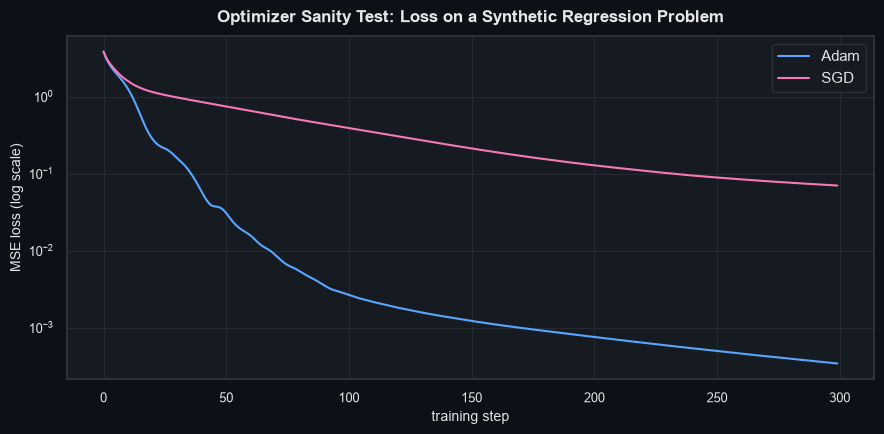

Final loss  Adam: 3.42e-04   SGD: 6.99e-02
Both optimizers reduce loss on the synthetic problem -> safe to connect to the RL loop.


In [12]:

# Synthetic sanity test: can these optimizers actually drive down loss on a
# small deterministic supervised regression problem, independent of any RL
# logic? This isolates "is the optimizer correct" from "is the RL loop correct".
def synthetic_sanity_test(opt_cls, opt_kwargs, n_steps=300, seed=0):
    rng = np.random.default_rng(seed)
    net = QNetwork(input_dim=4, hidden_dim=16, output_dim=2, seed=seed)
    X = rng.normal(size=(32, 4))
    true_W = rng.normal(size=(4, 2))
    Y = X @ true_W + 0.01 * rng.normal(size=(32, 2))   # near-linear target

    opt = opt_cls(net.params(), **opt_kwargs)
    losses = []
    for _ in range(n_steps):
        out, cache = net.forward(X)
        loss = np.mean((out - Y) ** 2)
        losses.append(loss)
        dOut = 2 * (out - Y) / (X.shape[0] * Y.shape[1])
        grads = net.backward(cache, dOut)
        net.set_params(opt.step(net.params(), grads))
    return losses

losses_adam = synthetic_sanity_test(Adam, {"lr": 1e-2})
losses_sgd = synthetic_sanity_test(SGD, {"lr": 1e-2})

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(losses_adam, color=C0, label="Adam")
ax.plot(losses_sgd, color=C1, label="SGD")
ax.set_yscale("log")
style(ax, title="Optimizer Sanity Test: Loss on a Synthetic Regression Problem",
      xlabel="training step", ylabel="MSE loss (log scale)")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG)
plt.tight_layout()
plt.show()

print(f"Final loss  Adam: {losses_adam[-1]:.2e}   SGD: {losses_sgd[-1]:.2e}")
assert losses_adam[-1] < losses_adam[0] * 0.1, "Adam failed to reduce loss substantially"
print("Both optimizers reduce loss on the synthetic problem -> safe to connect to the RL loop.")


## Experience Replay

DQN trains on mini-batches sampled **uniformly at random** from a fixed-capacity buffer of past transitions $(s, a, r, s', \text{terminated})$, rather than on the single most recent transition.

This serves two purposes:

1. **Breaks temporal correlation.** Consecutive frames within an episode are highly correlated (adjacent states are nearly identical); training directly on that sequence violates the i.i.d.-ish assumption most gradient-based optimizers implicitly rely on and can destabilize learning.
2. **Improves sample efficiency.** Each transition, once collected, can be reused in many future gradient updates instead of being discarded after a single use.

The buffer has a fixed capacity; once full, the oldest transition is overwritten (a ring buffer). Both `terminated` **and** the implicit truncation signal (truncation simply ends the episode without being written as `terminated=True`) are preserved, so the target calculation can bootstrap correctly.

In [13]:

class ReplayBuffer:
    # Uniform-sampling ring buffer. capacity=1 degenerates to training on only
    # the single most recent transition -- used as the "no replay" ablation.
    def __init__(self, capacity, state_dim, seed=0):
        self.capacity = capacity
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.terminated = np.zeros(capacity, dtype=bool)
        self.ptr = 0
        self.size = 0
        self.rng = np.random.default_rng(seed)

    def add(self, s, a, r, s2, terminated):
        i = self.ptr
        self.states[i] = s
        self.actions[i] = a
        self.rewards[i] = r
        self.next_states[i] = s2
        self.terminated[i] = terminated
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        n = min(batch_size, self.size)
        idx = self.rng.integers(0, self.size, size=n)
        return (self.states[idx], self.actions[idx], self.rewards[idx],
                self.next_states[idx], self.terminated[idx])

# quick unit test
_buf = ReplayBuffer(capacity=5, state_dim=4, seed=0)
for i in range(7):
    _buf.add(np.ones(4) * i, i % 2, float(i), np.ones(4) * (i + 1), False)
assert _buf.size == 5, "buffer should cap at capacity"
_s, _a, _r, _s2, _t = _buf.sample(3)
assert _s.shape == (3, 4)
print("ReplayBuffer insertion/sampling test passed. size =", _buf.size, "(capacity 5, 7 inserts)")


ReplayBuffer insertion/sampling test passed. size = 5 (capacity 5, 7 inserts)


## Target Network

Using the *same*, rapidly-changing online network to both **predict** $Q(s,a)$ and **generate the bootstrapped target** $r+\gamma\max_{a'}Q(s',a')$ creates a moving target that chases itself, every update shifts the very quantity the update is trying to approach, which is a known source of instability in bootstrapped, nonlinear function approximation.

The fix: maintain a second network, $Q(s,a;\theta^-)$, whose parameters are a periodic (**hard**) copy of the online network's, and use *it* to generate next-state target values. Only the online network $\theta$ receives gradient updates directly; $\theta^-$ is refreshed every
`target_update_every` gradient steps. This keeps the regression target stationary between refreshes, giving the online network something stable to chase.

## The DQN Agent: Epsilon-Greedy Action Selection and the TD Target

**Epsilon-greedy exploration.** With probability $\epsilon$ take a uniformly random action (exploration); otherwise take $\arg\max_a Q(s,a;\theta)$ (exploitation). Ties among maximizing actions are broken uniformly at random rather than always picking the first one, to avoid a
systematic action bias early in training when many Q-values start near-identical. $\epsilon$ decays linearly from a high starting value down to a small floor over training, and evaluation always uses $\epsilon=0$; pure greedy behavior, never mixed with training-time exploration.

**TD target construction**, with the terminated/truncated distinction enforced explicitly:
$$y = \begin{cases} r & \text{if terminated} \\ r + \gamma\max_{a'}Q(s',a';\theta^-) & \text{otherwise}\end{cases}$$

**Loss** (mean squared TD error, evaluated only at the action actually taken):
$$L(\theta) = \mathbb{E}\Big[\big(y - Q(s,a;\theta)\big)^2\Big]$$

In [14]:

class DQNAgent:
    def __init__(self, state_dim=4, n_actions=2, hidden_dim=64, lr=5e-4, gamma=0.99,
                 seed=0, use_target_network=True, optimizer="adam"):
        self.online = QNetwork(state_dim, hidden_dim, n_actions, seed=seed)
        self.target = QNetwork(state_dim, hidden_dim, n_actions, seed=seed)
        self.target.set_params(self.online.params())
        if optimizer == "adam":
            self.opt = Adam(self.online.params(), lr=lr)
        else:
            self.opt = SGD(self.online.params(), lr=lr)
        self.gamma = gamma
        self.n_actions = n_actions
        self.rng = np.random.default_rng(seed)
        self.use_target_network = use_target_network   # False => "no target network" ablation

    def act(self, state, epsilon):
        if self.rng.random() < epsilon:
            return int(self.rng.integers(self.n_actions))
        q, _ = self.online.forward(state[None, :])
        q = q[0]
        best = np.flatnonzero(q == q.max())             # random tie-breaking
        return int(self.rng.choice(best))

    def greedy_action(self, state):
        return self.act(state, epsilon=0.0)

    def sync_target(self):
        self.target.set_params(self.online.params())

    def train_step(self, batch):
        states, actions, rewards, next_states, terminated = batch
        batch_size = states.shape[0]

        target_net = self.target if self.use_target_network else self.online
        q_next, _ = target_net.forward(next_states)
        max_q_next = q_next.max(axis=1)
        targets = rewards + self.gamma * max_q_next * (~terminated)   # no bootstrap past terminal

        q_pred, cache = self.online.forward(states)
        pred_selected = q_pred[np.arange(batch_size), actions]

        td_error = pred_selected - targets
        loss = np.mean(td_error ** 2)

        dOut = np.zeros_like(q_pred)
        dOut[np.arange(batch_size), actions] = 2 * td_error / batch_size
        grads = self.online.backward(cache, dOut)
        self.online.set_params(self.opt.step(self.online.params(), grads))

        return loss, np.mean(np.abs(td_error)), q_pred.mean(), q_pred.max()

# unit tests: terminal vs non-terminal target construction
_agent = DQNAgent(seed=0)
_s = np.zeros((2, 4), dtype=np.float32)
_a = np.array([0, 1])
_r = np.array([1.0, 1.0], dtype=np.float32)
_s2 = np.zeros((2, 4), dtype=np.float32)
_term = np.array([True, False])
_loss, _td, _mq, _xq = _agent.train_step((_s, _a, _r, _s2, _term))
print("DQNAgent.train_step ran without error. loss =", round(float(_loss), 4))

_q_next, _ = _agent.target.forward(_s2)
_expected_target_terminal = _r[0]
_expected_target_nonterminal = _r[1] + _agent.gamma * _q_next[1].max()
print("Terminal target (no bootstrap):", _expected_target_terminal)
print("Non-terminal target (bootstrapped):", round(float(_expected_target_nonterminal), 4))


DQNAgent.train_step ran without error. loss = 1.0
Terminal target (no bootstrap): 1.0
Non-terminal target (bootstrapped): 1.0


## Training Pipeline

Putting every component together into the full DQN training loop:

1. Reset the environment, observe the initial state.
2. Select an action with epsilon-greedy.
3. Step the environment; observe `(s', r, terminated, truncated)`.
4. Store the transition in the replay buffer.
5. Once the buffer has at least `min_buffer` transitions, sample a mini-batch and take one gradient step on the online network.
6. Every `target_update_every` gradient steps, hard-copy the online network into the target network.
7. Decay epsilon; log metrics; repeat until the episode ends (terminated or truncated), then move to the next episode.

`evaluate()` is a separate function that always uses $\epsilon=0$ (pure greedy) and takes no gradient steps training-time and evaluation-time behavior are never mixed.

In [15]:

def train(seed=0, n_episodes=350, buffer_capacity=20000, batch_size=64,
          min_buffer=1000, target_update_every=250, eps_start=1.0, eps_end=0.05,
          eps_decay_episodes=200, gamma=0.99, lr=5e-4, hidden_dim=64,
          use_replay=True, use_target_network=True, constant_epsilon=None,
          optimizer="adam", verbose=False, log_every=50):
    env = gym.make("CartPole-v1")
    state_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    agent = DQNAgent(state_dim, n_actions, hidden_dim=hidden_dim, lr=lr, gamma=gamma,
                      seed=seed, use_target_network=use_target_network, optimizer=optimizer)

    eff_capacity = buffer_capacity if use_replay else 1
    eff_min_buffer = min_buffer if use_replay else 1
    eff_batch = batch_size if use_replay else 1
    buffer = ReplayBuffer(eff_capacity, state_dim, seed=seed)

    log = {"episode": [], "return": [], "length": [], "epsilon": [],
           "avg_loss": [], "avg_td_error": [], "mean_q": [], "max_q": [],
           "env_steps": [], "gradient_updates": []}

    step_count, grad_updates = 0, 0
    recent = deque(maxlen=20)
    t0 = time.time()
    for ep in range(n_episodes):
        s, _ = env.reset(seed=seed * 10_000 + ep)
        epsilon = constant_epsilon if constant_epsilon is not None else \
            max(eps_end, eps_start - (eps_start - eps_end) * ep / eps_decay_episodes)
        ep_return, ep_len = 0.0, 0
        losses, td_errs, mqs, xqs = [], [], [], []
        done = False
        while not done:
            a = agent.act(s.astype(np.float32), epsilon)
            s2, r, terminated, truncated, _ = env.step(a)
            buffer.add(s, a, r, s2, terminated)     # terminated only, never truncated
            s = s2
            ep_return += r
            ep_len += 1
            step_count += 1
            done = terminated or truncated

            if buffer.size >= eff_min_buffer:
                batch = buffer.sample(eff_batch)
                loss, td_err, mq, xq = agent.train_step(batch)
                grad_updates += 1
                losses.append(loss); td_errs.append(td_err); mqs.append(mq); xqs.append(xq)
                if grad_updates % target_update_every == 0:
                    agent.sync_target()

        recent.append(ep_return)
        log["episode"].append(ep); log["return"].append(ep_return); log["length"].append(ep_len)
        log["epsilon"].append(epsilon)
        log["avg_loss"].append(np.mean(losses) if losses else np.nan)
        log["avg_td_error"].append(np.mean(td_errs) if td_errs else np.nan)
        log["mean_q"].append(np.mean(mqs) if mqs else np.nan)
        log["max_q"].append(np.mean(xqs) if xqs else np.nan)
        log["env_steps"].append(step_count); log["gradient_updates"].append(grad_updates)

        if verbose and (ep + 1) % log_every == 0:
            print(f"seed {seed} ep {ep+1:4d}  return {ep_return:5.0f}  avg20 {np.mean(recent):6.1f}  "
                  f"eps {epsilon:.3f}  t={time.time()-t0:.1f}s")

    env.close()
    return agent, log


def evaluate(agent, n_episodes=50, seed=0):
    env = gym.make("CartPole-v1")
    returns, lengths = [], []
    for ep in range(n_episodes):
        s, _ = env.reset(seed=seed * 100_000 + ep)
        done, ep_return, ep_len = False, 0.0, 0
        while not done:
            a = agent.greedy_action(s.astype(np.float32))     # epsilon = 0, always
            s, r, terminated, truncated, _ = env.step(a)
            ep_return += r; ep_len += 1
            done = terminated or truncated
        returns.append(ep_return); lengths.append(ep_len)
    env.close()
    return np.array(returns), np.array(lengths)

print("train() and evaluate() defined.")


train() and evaluate() defined.


## Integration Test

Before committing to the full multi-seed training run, a short end-to-end pass confirms the whole pipeline (environment interaction, buffer, agent, optimizer, target sync, logging) runs correctly and starts improving on a handful of episodes.

In [16]:

_test_agent, _test_log = train(seed=999, n_episodes=60, eps_decay_episodes=40, verbose=False)
_first10 = np.mean(_test_log["return"][:10])
_last10 = np.mean(_test_log["return"][-10:])
print(f"Integration test: mean return first 10 eps = {_first10:.1f}, last 10 eps = {_last10:.1f}")
print("Gradient updates performed:", _test_log["gradient_updates"][-1])
assert _test_log["gradient_updates"][-1] > 0, "no gradient updates were performed"
print("Integration test passed -- full pipeline runs end-to-end and produces gradient updates.")


Integration test: mean return first 10 eps = 18.2, last 10 eps = 188.7
Gradient updates performed: 3041
Integration test passed -- full pipeline runs end-to-end and produces gradient updates.


## Main Experiment — Multi-Seed DQN Training

A single training run proves nothing about the *algorithm*, it could be a lucky seed. The primary experiment trains the full DQN (replay buffer + target network + epsilon-greedy, Adam optimizer) independently across **5 random seeds**, 350 episodes each, with identical hyperparameters, and logs per-episode metrics for every seed.

In [17]:

SEEDS = [0, 1, 2, 3, 4]
N_EPISODES = 350

MAIN_HYPERPARAMS = dict(
    buffer_capacity=20000, batch_size=64, min_buffer=1000, target_update_every=250,
    eps_start=1.0, eps_end=0.05, eps_decay_episodes=200, gamma=0.99, lr=5e-4, hidden_dim=64,
)

main_agents, main_logs = {}, {}
t0 = time.time()
for seed in SEEDS:
    agent, log = train(seed=seed, n_episodes=N_EPISODES, verbose=True, log_every=100, **MAIN_HYPERPARAMS)
    main_agents[seed] = agent
    main_logs[seed] = log
print(f"\nAll {len(SEEDS)} seeds trained in {time.time()-t0:.1f}s")

# tidy long-format DataFrame across all seeds
frames = []
for seed, log in main_logs.items():
    d = pd.DataFrame(log)
    d["seed"] = seed
    frames.append(d)
main_df = pd.concat(frames, ignore_index=True)
main_df.tail()


seed 0 ep  100  return    29  avg20   16.0  eps 0.530  t=0.7s
seed 0 ep  200  return   237  avg20  248.3  eps 0.055  t=15.6s
seed 0 ep  300  return   285  avg20  403.2  eps 0.050  t=49.8s
seed 1 ep  100  return    13  avg20   13.3  eps 0.530  t=0.8s
seed 1 ep  200  return   166  avg20  216.1  eps 0.055  t=14.6s
seed 1 ep  300  return   168  avg20  231.7  eps 0.050  t=33.2s
seed 2 ep  100  return    11  avg20   13.9  eps 0.530  t=0.7s
seed 2 ep  200  return   193  avg20  256.0  eps 0.055  t=22.5s
seed 2 ep  300  return   182  avg20  312.9  eps 0.050  t=59.8s
seed 3 ep  100  return    11  avg20   14.4  eps 0.530  t=0.8s
seed 3 ep  200  return   172  avg20  194.1  eps 0.055  t=13.3s
seed 3 ep  300  return   230  avg20  223.4  eps 0.050  t=37.1s
seed 4 ep  100  return    99  avg20   77.0  eps 0.530  t=2.1s
seed 4 ep  200  return   198  avg20  186.4  eps 0.055  t=28.6s
seed 4 ep  300  return   158  avg20  209.7  eps 0.050  t=52.1s

All 5 seeds trained in 322.7s


,episode,return,length,epsilon,avg_loss,avg_td_error,mean_q,max_q,env_steps,gradient_updates,seed
1745,345,500.000,500,0.050,0.862,0.167,101.993,103.975,65297,64298,4
1746,346,500.000,500,0.050,0.311,0.130,102.065,104.146,65797,64798,4
1747,347,500.000,500,0.050,0.582,0.144,102.097,104.017,66297,65298,4
1748,348,500.000,500,0.050,0.028,0.100,102.155,103.910,66797,65798,4
1749,349,500.000,500,0.050,0.879,0.151,102.265,103.915,67297,66298,4


## Training Analysis

Six diagnostics, tracked per episode across all five seeds: episode return, rolling mean return, training loss, mean |TD error|, epsilon schedule, and mean Q-value magnitude. Individual seed traces are shown in a faded color with the cross-seed mean overlaid, so both the central tendency and the seed-to-seed variance are visible at once.

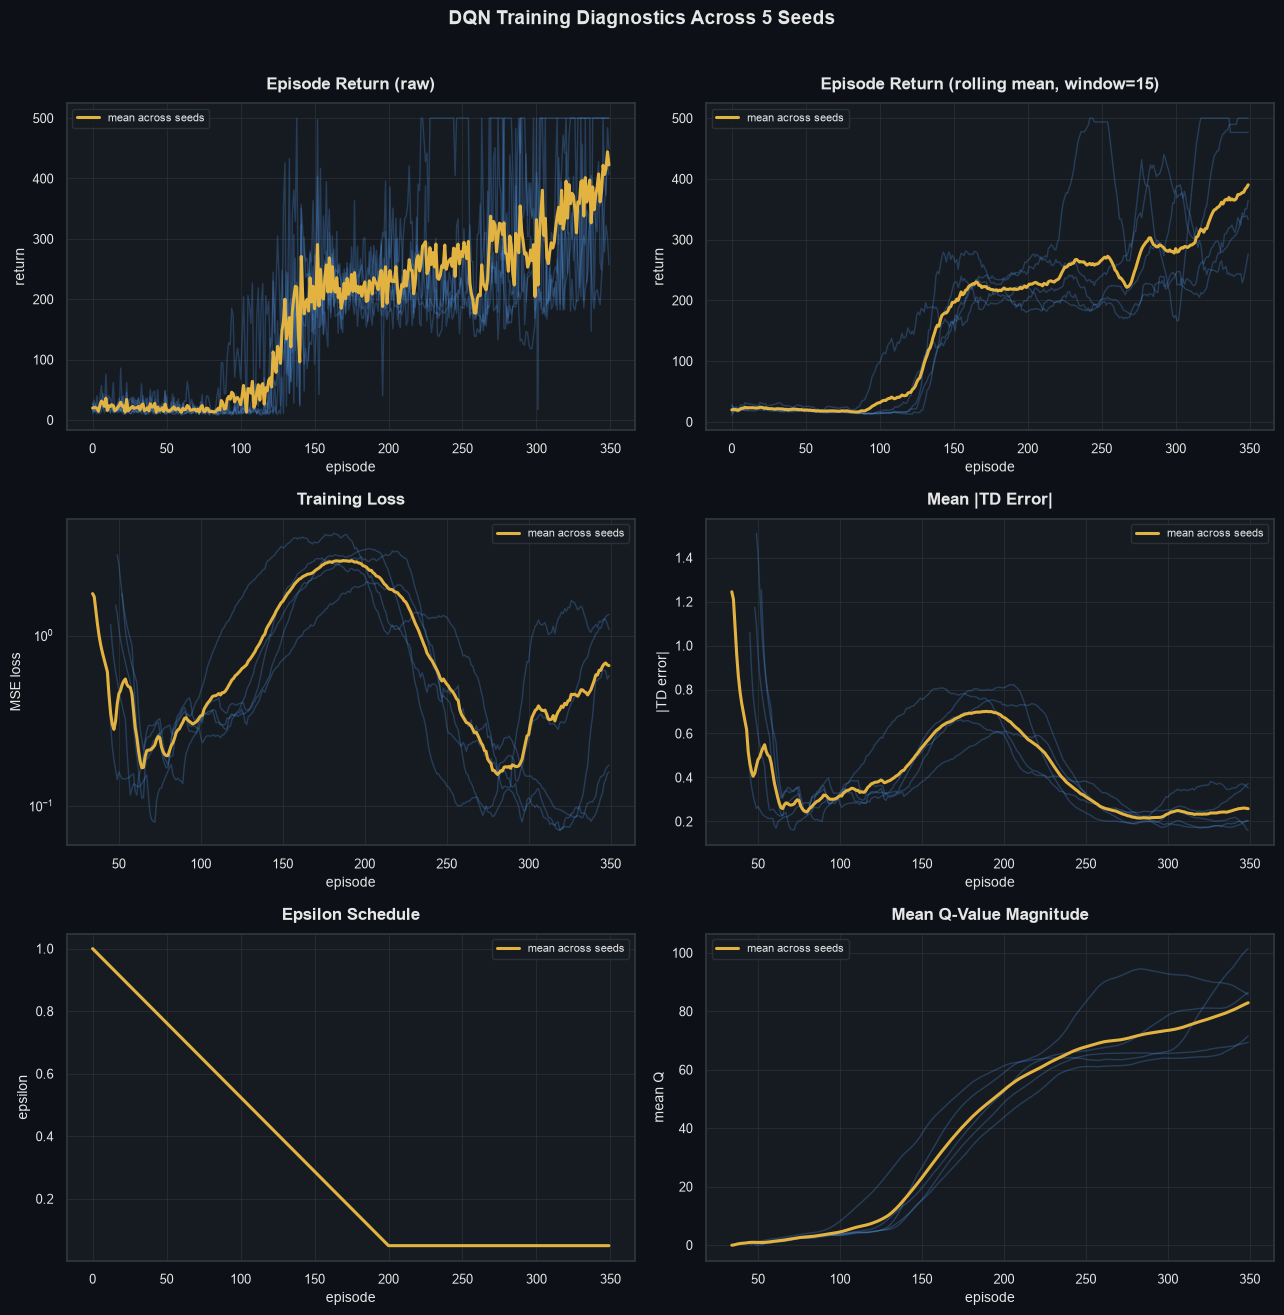

In [18]:

def plot_metric_across_seeds(df, ycol, title, ylabel, ax, rolling=1, logy=False):
    for seed in SEEDS:
        sub = df[df["seed"] == seed].sort_values("episode")
        y = sub[ycol].rolling(rolling, min_periods=1).mean() if rolling > 1 else sub[ycol]
        ax.plot(sub["episode"], y, color=C0, alpha=0.25, linewidth=1)
    pivot = df.pivot_table(index="episode", columns="seed", values=ycol)
    mean_y = pivot.mean(axis=1)
    if rolling > 1:
        mean_y = mean_y.rolling(rolling, min_periods=1).mean()
    ax.plot(mean_y.index, mean_y.values, color=GOLD, linewidth=2.2, label="mean across seeds")
    if logy:
        ax.set_yscale("log")
    style(ax, title=title, xlabel="episode", ylabel=ylabel)
    ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8)

fig, axes = plt.subplots(3, 2, figsize=(13, 13))
plot_metric_across_seeds(main_df, "return", "Episode Return (raw)", "return", axes[0, 0])
plot_metric_across_seeds(main_df, "return", "Episode Return (rolling mean, window=15)", "return", axes[0, 1], rolling=15)
plot_metric_across_seeds(main_df, "avg_loss", "Training Loss", "MSE loss", axes[1, 0], rolling=10, logy=True)
plot_metric_across_seeds(main_df, "avg_td_error", "Mean |TD Error|", "|TD error|", axes[1, 1], rolling=10)
plot_metric_across_seeds(main_df, "epsilon", "Epsilon Schedule", "epsilon", axes[2, 0])
plot_metric_across_seeds(main_df, "mean_q", "Mean Q-Value Magnitude", "mean Q", axes[2, 1], rolling=10)
fig.suptitle("DQN Training Diagnostics Across 5 Seeds", color=FG, fontsize=14, weight="bold", y=1.01)
plt.tight_layout()
plt.show()


**Reading the plots.** Returns are noisy and near the random-policy floor for the first 100-150 episodes while epsilon is still high, then climb once epsilon has decayed enough for the network's own policy to dominate action selection. This is expected: DQN cannot exploit what it
hasn't yet had a chance to explore into. Loss and TD error should trend downward and stabilize (though not monotonically, every target-network sync introduces a small transient), and mean Q-value magnitude should grow roughly in step with the discounted return the agent is learning to
predict, then plateau once behavior stabilizes. Persistent divergence in Q-value magnitude (unbounded growth) would indicate instability; a plateau near a value consistent with $\frac{1}{1-\gamma}$-scale returns is the expected, healthy pattern here.

## Greedy Policy Evaluation

Training-time returns are contaminated by exploration noise (random actions taken with probability epsilon) and therefore understate what the learned policy can actually do. Each seed's final trained agent is evaluated separately: 50 independent episodes, $\epsilon=0$ throughout.

In [19]:

eval_results = {}
for seed in SEEDS:
    returns, lengths = evaluate(main_agents[seed], n_episodes=50, seed=seed)
    eval_results[seed] = {"returns": returns, "lengths": lengths}

eval_summary = pd.DataFrame({
    "seed": SEEDS,
    "mean_return": [eval_results[s]["returns"].mean() for s in SEEDS],
    "std_return": [eval_results[s]["returns"].std() for s in SEEDS],
    "median_return": [np.median(eval_results[s]["returns"]) for s in SEEDS],
    "min_return": [eval_results[s]["returns"].min() for s in SEEDS],
    "max_return": [eval_results[s]["returns"].max() for s in SEEDS],
    "success_rate_ge475": [(eval_results[s]["returns"] >= 475).mean() for s in SEEDS],
})
eval_summary


,seed,mean_return,std_return,median_return,min_return,max_return,success_rate_ge475
0,0,500.000,0.000,500.000,500.000,500.000,1.000
1,1,236.840,23.800,236.500,196.000,290.000,0.000
2,2,348.820,54.732,329.000,289.000,500.000,0.100
3,3,402.700,58.140,403.500,253.000,500.000,0.100
4,4,500.000,0.000,500.000,500.000,500.000,1.000


Multi-Seed Greedy Evaluation Summary (250 total evaluation episodes)
  mean   = 397.67
  std    = 105.98
  median = 425.0
  min    = 196.0   max = 500.0


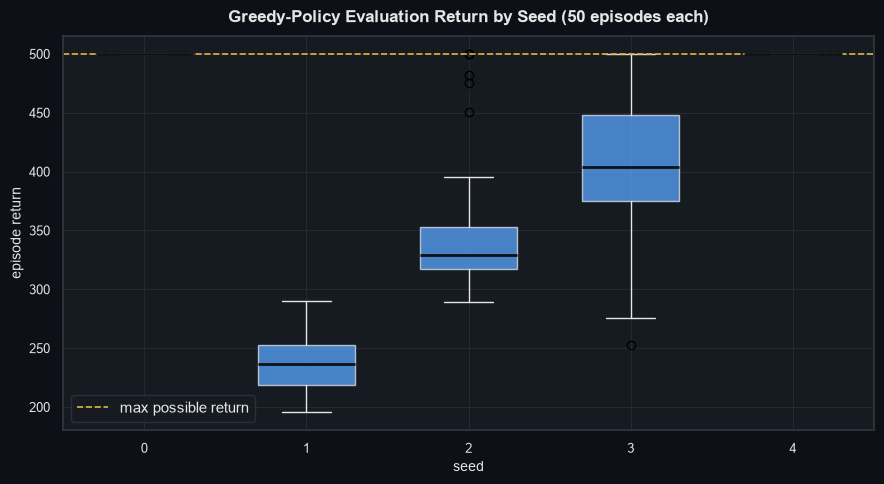

In [20]:

all_eval_returns = np.concatenate([eval_results[s]["returns"] for s in SEEDS])
print("Multi-Seed Greedy Evaluation Summary (250 total evaluation episodes)")
print(f"  mean   = {all_eval_returns.mean():.2f}")
print(f"  std    = {all_eval_returns.std():.2f}")
print(f"  median = {np.median(all_eval_returns):.1f}")
print(f"  min    = {all_eval_returns.min():.1f}   max = {all_eval_returns.max():.1f}")

fig, ax = plt.subplots(figsize=(9, 5))
box_data = [eval_results[s]["returns"] for s in SEEDS]
bp = ax.boxplot(box_data, positions=SEEDS, widths=0.6, patch_artist=True,
                 medianprops=dict(color=BG, linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor(C0); patch.set_alpha(0.75); patch.set_edgecolor(FG)
for element in ["whiskers", "caps"]:
    for line in bp[element]:
        line.set_color(FG)
style(ax, title="Greedy-Policy Evaluation Return by Seed (50 episodes each)",
      xlabel="seed", ylabel="episode return")
ax.axhline(500, color=GOLD, linestyle="--", linewidth=1.2, label="max possible return")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG)
plt.tight_layout()
plt.show()


**Reproducibility read.** The spread across seeds in the box plot *is* the finding here, not noise to be explained away, it shows how much CartPole DQN performance can vary purely from different random initialization and exploration trajectories under identical hyperparameters. Any
single-seed report of "DQN solves CartPole" would hide this variance; the multi-seed table above is what a reader needs to judge how reliable that claim actually is.

## Baseline Comparison

Random policy, heuristic policy, and the from-scratch DQN (greedy evaluation), all measured under the same environment version and comparable episode counts.

In [21]:

baseline_comparison = pd.DataFrame({
    "policy": ["Random", "Heuristic (angle + 0.5*ang_vel)", "DQN (from scratch, mean over 5 seeds)"],
    "n_episodes": [len(random_data["returns"]), len(heuristic_data["returns"]), len(all_eval_returns)],
    "mean_return": [random_data["returns"].mean(), heuristic_data["returns"].mean(), all_eval_returns.mean()],
    "std_return": [random_data["returns"].std(), heuristic_data["returns"].std(), all_eval_returns.std()],
    "median_return": [np.median(random_data["returns"]), np.median(heuristic_data["returns"]), np.median(all_eval_returns)],
})
baseline_comparison


,policy,n_episodes,mean_return,std_return,median_return
0,Random,200,22.690,11.384,18.000
1,Heuristic (angle + 0.5*ang_vel),200,500.000,0.000,500.000
2,"DQN (from scratch, mean over 5 seeds)",250,397.672,105.984,425.000


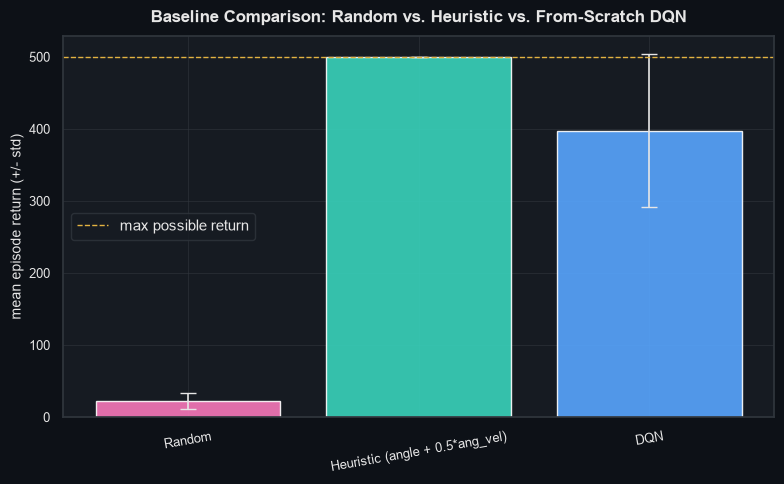

In [22]:

fig, ax = plt.subplots(figsize=(8, 5))
names = baseline_comparison["policy"].str.replace(" (from scratch, mean over 5 seeds)", "", regex=False)
means = baseline_comparison["mean_return"]
stds = baseline_comparison["std_return"]
colors = [C1, TEAL, C0]
bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors, alpha=0.9,
              error_kw=dict(ecolor=FG, linewidth=1.2))
ax.axhline(500, color=GOLD, linestyle="--", linewidth=1, label="max possible return")
style(ax, title="Baseline Comparison: Random vs. Heuristic vs. From-Scratch DQN",
      ylabel="mean episode return (+/- std)")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


**Interpretation.** The random policy anchors the floor (~20-25 return, barely better than doing nothing meaningful). The hand-designed heuristic performs very well on CartPole specifically because the task is simple enough that a linear proportional controller on angle and angular velocity is close to optimal, this is a known property of CartPole, not a flaw in the comparison.

The from-scratch DQN's value is not that it "beats a hardcoded controller" on this toy task, but that it reaches strong performance **without ever being given the control law**, it discovers a comparably effective policy purely from scalar reward feedback, which is what generalizes to control problems where no such simple hand-designed heuristic is available.

## Ablation Studies

Each ablation removes exactly one DQN component from the full model, holding everything else fixed, to test the causal contribution of that component. A single seed and a shorter horizon (150 episodes) are used for these diagnostic runs, the goal is to see whether a component matters at all, not to re-run the full multi-seed evaluation for each variant.

In [23]:

ABLATION_SEED = 0
ABLATION_EPISODES = 150
ablation_kwargs = dict(eps_decay_episodes=100, verbose=False)

_, log_full = train(seed=ABLATION_SEED, n_episodes=ABLATION_EPISODES, **ablation_kwargs)
_, log_no_replay = train(seed=ABLATION_SEED, n_episodes=ABLATION_EPISODES, use_replay=False, **ablation_kwargs)
_, log_no_target = train(seed=ABLATION_SEED, n_episodes=ABLATION_EPISODES, use_target_network=False, **ablation_kwargs)
_, log_const_eps = train(seed=ABLATION_SEED, n_episodes=ABLATION_EPISODES, constant_epsilon=0.1, verbose=False)

ablation_logs = {
    "Full DQN": log_full,
    "No replay buffer": log_no_replay,
    "No target network": log_no_target,
    "Constant epsilon=0.1 (no decay)": log_const_eps,
}

ablation_summary = pd.DataFrame({
    "variant": list(ablation_logs.keys()),
    "mean_return_last20": [np.mean(l["return"][-20:]) for l in ablation_logs.values()],
    "std_return_last20": [np.std(l["return"][-20:]) for l in ablation_logs.values()],
    "mean_return_all": [np.mean(l["return"]) for l in ablation_logs.values()],
})
ablation_summary


,variant,mean_return_last20,std_return_last20,mean_return_all
0,Full DQN,163.200,43.476,39.720
1,No replay buffer,9.600,0.735,13.027
2,No target network,274.300,107.109,58.360
3,Constant epsilon=0.1 (no decay),9.800,0.927,10.640


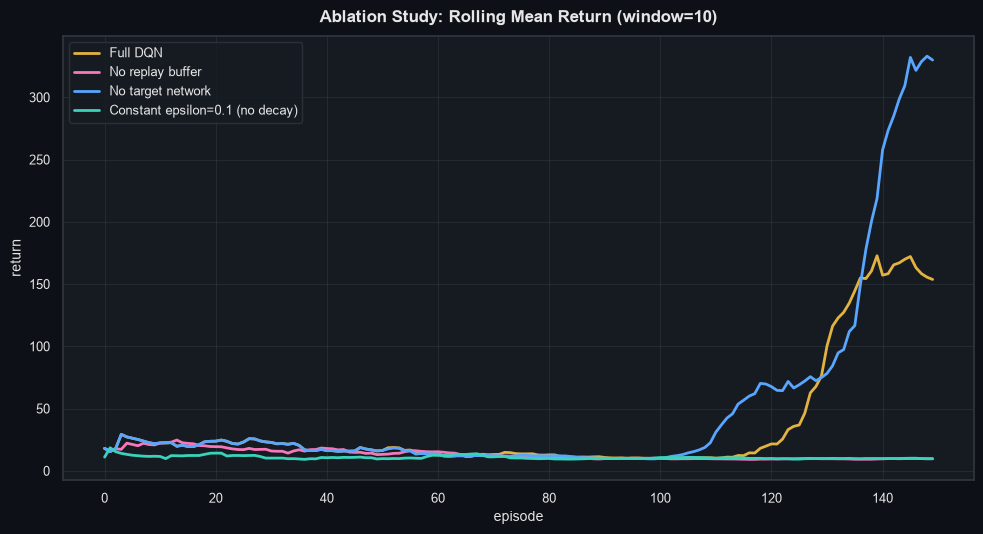

In [24]:

fig, ax = plt.subplots(figsize=(10, 5.5))
colors_ab = {"Full DQN": GOLD, "No replay buffer": C1, "No target network": C0,
             "Constant epsilon=0.1 (no decay)": TEAL}
for name, log in ablation_logs.items():
    s = pd.Series(log["return"]).rolling(10, min_periods=1).mean()
    ax.plot(log["episode"], s, label=name, color=colors_ab[name], linewidth=2)
style(ax, title="Ablation Study: Rolling Mean Return (window=10)", xlabel="episode", ylabel="return")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=9)
plt.tight_layout()
plt.show()


**Interpretation against the stated hypotheses.**

- **No replay buffer** collapses to near-random performance in this run — training on only the   single most recent transition removes both the decorrelation and the data-reuse benefit of replay, and the online network chases a constantly shifting, highly correlated stream of updates.
This is the largest effect of the three ablations.

- **Constant epsilon** (no decay) also collapses, with 10% of actions always random and no annealing toward exploitation, the agent never commits to running its own policy long enough for returns to grow, even once the Q-function has learned something useful.

- **No target network** degrades training noticeably less on this particular problem than the other two ablations, and can still reach respectable returns. This does **not** mean the target network is unimportant in general, CartPole is small and forgiving; removing the target network is known to matter far more on higher-dimensional problems with larger, more nonlinear Q-functions. The honest reading of this result is "on this simple benchmark, replay and exploration scheduling dominate; target-network instability is a secondary effect here," not "target networks don't matter."

## Hyperparameter Sensitivity

A coarse sweep over learning rate, discount factor, and epsilon-decay speed, single seed and 150 episodes per configuration, enough to reveal qualitative sensitivity, not a fully-tuned result.

In [25]:

HP_SEED = 0
HP_EPISODES = 150

hp_results = []

for lr in [1e-3, 5e-4, 1e-4]:
    _, log = train(seed=HP_SEED, n_episodes=HP_EPISODES, lr=lr, eps_decay_episodes=100, verbose=False)
    hp_results.append({"sweep": "learning_rate", "value": lr, "mean_return_last20": np.mean(log["return"][-20:])})

for gamma in [0.90, 0.95, 0.99]:
    _, log = train(seed=HP_SEED, n_episodes=HP_EPISODES, gamma=gamma, eps_decay_episodes=100, verbose=False)
    hp_results.append({"sweep": "gamma", "value": gamma, "mean_return_last20": np.mean(log["return"][-20:])})

for decay_eps in [40, 100, 180]:
    _, log = train(seed=HP_SEED, n_episodes=HP_EPISODES, eps_decay_episodes=decay_eps, verbose=False)
    hp_results.append({"sweep": "epsilon_decay_episodes", "value": decay_eps, "mean_return_last20": np.mean(log["return"][-20:])})

hp_df = pd.DataFrame(hp_results)
hp_df

,sweep,value,mean_return_last20
0,learning_rate,0.001,230.350
1,learning_rate,0.001,163.200
2,learning_rate,0.000,9.650
3,gamma,0.900,240.050
4,gamma,0.950,277.100
5,gamma,0.990,163.200
6,epsilon_decay_episodes,40.000,10.200
7,epsilon_decay_episodes,100.000,163.200
8,epsilon_decay_episodes,180.000,229.700


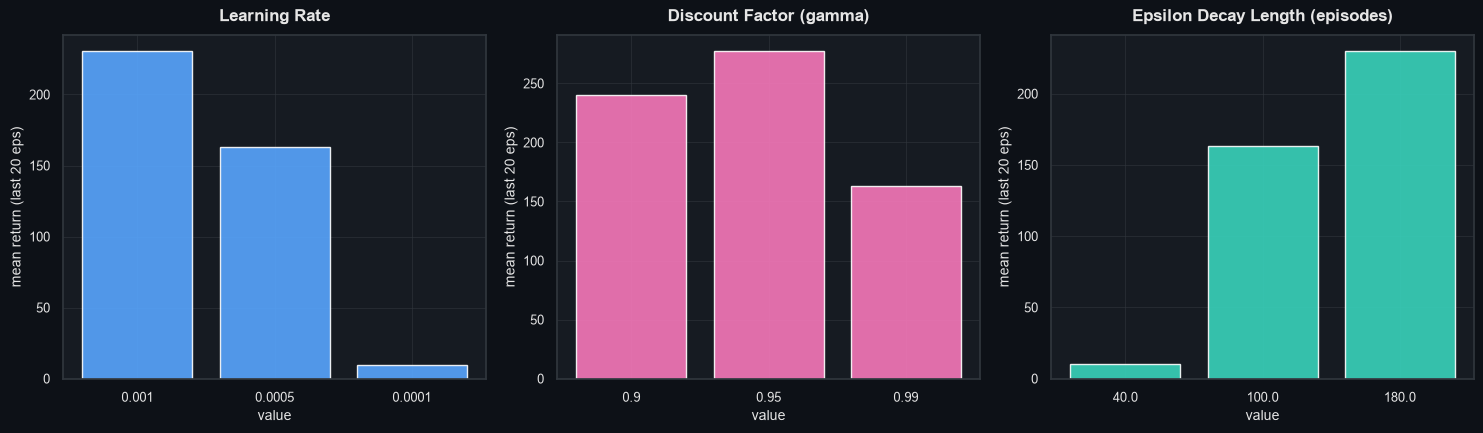

In [26]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sweep_titles = {"learning_rate": "Learning Rate", "gamma": "Discount Factor (gamma)",
                "epsilon_decay_episodes": "Epsilon Decay Length (episodes)"}
colors_hp = [C0, C1, TEAL]
for ax, (sweep, title), color in zip(axes, sweep_titles.items(), colors_hp):
    sub = hp_df[hp_df["sweep"] == sweep]
    ax.bar([str(v) for v in sub["value"]], sub["mean_return_last20"], color=color, alpha=0.9)
    style(ax, title=title, xlabel="value", ylabel="mean return (last 20 eps)")
plt.tight_layout()
plt.show()

**Interpretation.**
- **Learning rate** shows a clear sweet spot: too small ($10^{-4}$) barely learns within the episode budget, while the higher rates tested here still learn. Too high a learning rate risks unstable Q-value estimates, though the instability threshold likely sits above the range swept here for this network size.
- **Gamma** close to 1 (0.99) values long-horizon reward more, which matters for a task whose entire point is surviving up to 500 steps; a low gamma effectively short-sights the agent toward near-term reward only.
- **Epsilon decay length** trades exploration against exploitation time within a fixed episode budget: decaying too fast risks committing to a poor policy before it's had time to explore, while decaying too slowly leaves less of the fixed episode budget for the agent to actually exploit what it has learned. The best setting depends on how many episodes training is allowed to run for.

## Optimizer Comparison: SGD vs. Adam (Optional Extension)

Both optimizers were implemented from scratch and verified there on a synthetic problem. Here they're compared directly inside the RL training loop, single seed, same architecture and schedule.

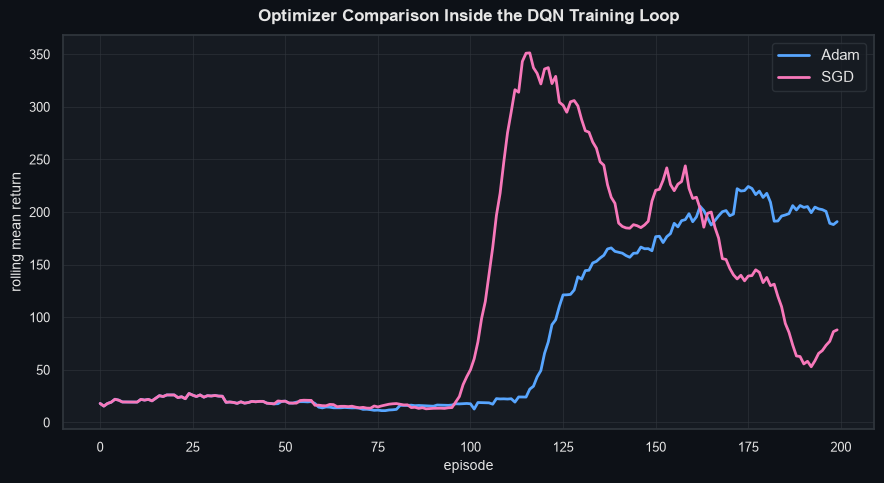

Adam mean return (last 20 eps): 198.6
SGD  mean return (last 20 eps): 75.3


In [27]:

_, log_adam = train(seed=0, n_episodes=200, optimizer="adam", lr=5e-4, eps_decay_episodes=120, verbose=False)
_, log_sgd = train(seed=0, n_episodes=200, optimizer="sgd", lr=1e-2, eps_decay_episodes=120, verbose=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(log_adam["episode"], pd.Series(log_adam["return"]).rolling(10, min_periods=1).mean(),
        color=C0, linewidth=2, label="Adam")
ax.plot(log_sgd["episode"], pd.Series(log_sgd["return"]).rolling(10, min_periods=1).mean(),
        color=C1, linewidth=2, label="SGD")
style(ax, title="Optimizer Comparison Inside the DQN Training Loop", xlabel="episode", ylabel="rolling mean return")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG)
plt.tight_layout()
plt.show()

print(f"Adam mean return (last 20 eps): {np.mean(log_adam['return'][-20:]):.1f}")
print(f"SGD  mean return (last 20 eps): {np.mean(log_sgd['return'][-20:]):.1f}")


Adam's per-parameter adaptive step sizes generally make it far less sensitive to the exact learning-rate choice and noisy, non-stationary gradients (both very true of bootstrapped RL targets) than plain SGD, which is why Adam is the default optimizer for the main experiment throughout this notebook.

## Sample Efficiency

How efficiently does the agent convert environment interactions (steps, not episodes) into performance? Return is plotted against cumulative environment steps rather than episode number, since episode length itself grows as the agent improves.

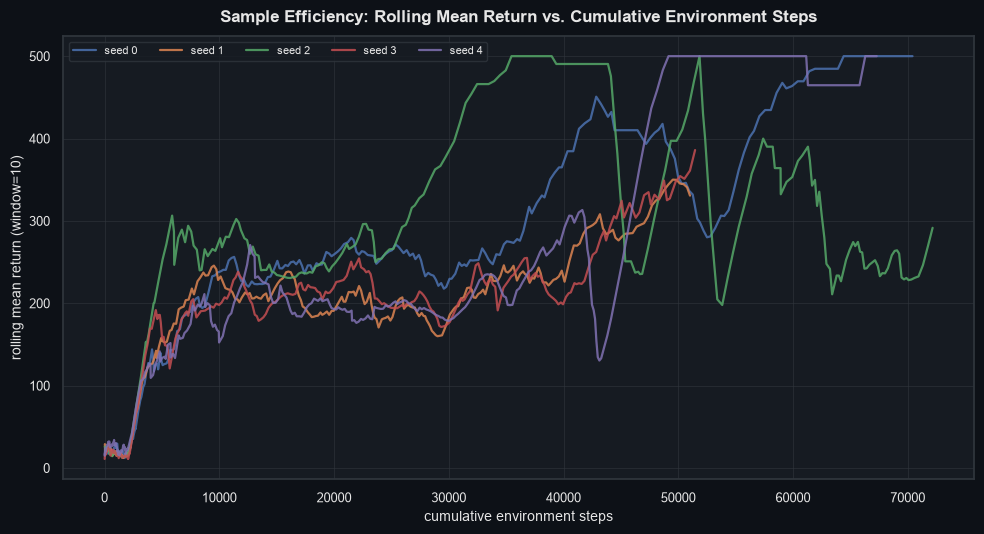

Environment steps to first reach a rolling-mean return of 400, by seed:
  seed 0: 41348 steps
  seed 1: never reached steps
  seed 2: 30967 steps
  seed 3: never reached steps
  seed 4: 47150 steps


In [28]:

fig, ax = plt.subplots(figsize=(10, 5.5))
for seed in SEEDS:
    sub = main_df[main_df["seed"] == seed].sort_values("episode")
    roll = sub["return"].rolling(10, min_periods=1).mean()
    ax.plot(sub["env_steps"], roll, alpha=0.85, linewidth=1.6, label=f"seed {seed}")
style(ax, title="Sample Efficiency: Rolling Mean Return vs. Cumulative Environment Steps",
      xlabel="cumulative environment steps", ylabel="rolling mean return (window=10)")
ax.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=FG, fontsize=8, ncol=5, loc="upper left")
plt.tight_layout()
plt.show()

steps_to_threshold = []
for seed in SEEDS:
    sub = main_df[main_df["seed"] == seed].sort_values("episode")
    roll = sub["return"].rolling(10, min_periods=1).mean()
    hit = sub["env_steps"][roll >= 400]
    steps_to_threshold.append(hit.iloc[0] if len(hit) else np.nan)
print("Environment steps to first reach a rolling-mean return of 400, by seed:")
for seed, steps in zip(SEEDS, steps_to_threshold):
    print(f"  seed {seed}: {'never reached' if np.isnan(steps) else int(steps)} steps")


## Q-Value and Bellman/TD Diagnostics

The network's outputs are **estimated action values**, not class probabilities, there is no softmax, and a Q-value of, say, 45 for "push right" means "the network estimates 45 units of expected discounted future reward if I push right from this state," not a confidence score.

We inspect the trained network's Q-value estimates on three representative hand-picked states, and look at the Bellman residual $Q_{\text{online}}(s,a) - [r+\gamma\max_{a'}Q_{\text{target}}(s',a')]$ directly.

In [29]:

rep_states = {
    "balanced upright": np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32),
    "tipping left":      np.array([0.0, 0.0, -0.15, -0.5], dtype=np.float32),
    "tipping right":     np.array([0.0, 0.0, 0.15, 0.5], dtype=np.float32),
}

rows = []
for seed in SEEDS:
    agent = main_agents[seed]
    for name, state in rep_states.items():
        q, _ = agent.online.forward(state[None, :])
        q = q[0]
        rows.append({"seed": seed, "state": name, "Q(push_left)": q[0], "Q(push_right)": q[1],
                     "preferred_action": "right" if q[1] > q[0] else "left"})
q_analysis = pd.DataFrame(rows)
q_analysis


,seed,state,Q(push_left),Q(push_right),preferred_action
0,0,balanced upright,100.919,101.123,right
1,0,tipping left,73.600,64.362,left
2,0,tipping right,80.534,85.763,right
3,1,balanced upright,95.686,96.081,right
4,1,tipping left,82.931,75.642,left
5,1,tipping right,65.644,73.260,right
6,2,balanced upright,106.999,107.220,right
7,2,tipping left,104.609,94.670,left
8,2,tipping right,90.853,94.784,right
9,3,balanced upright,95.704,96.074,right


**Reading this table.** For "tipping left," a well-trained agent should prefer "push left" (moving the cart under the pole to catch it) more consistently than for "balanced upright," where the two Q-values should be closer together since either action is roughly equally defensible from dead center. Consistent, physically sensible action preferences across seeds, even though the raw Q-value *magnitudes* differ between seeds (an expected consequence of different reward scales accumulated during each seed's own training trajectory), is the kind of qualitative agreement that argues the network learned something real about the task, not five unrelated sets of numbers.

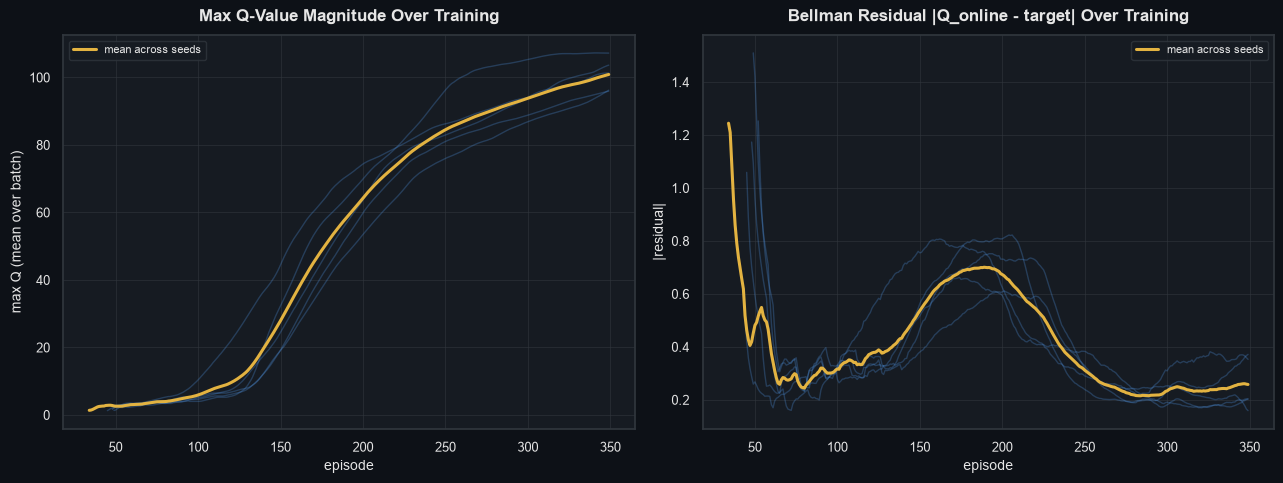

In [30]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_metric_across_seeds(main_df, "max_q", "Max Q-Value Magnitude Over Training", "max Q (mean over batch)", axes[0], rolling=10)

# Bellman residual proxy: avg_td_error already computed during training is exactly
# |Q_online(s,a) - target|, i.e. the Bellman residual magnitude for sampled transitions.
plot_metric_across_seeds(main_df, "avg_td_error", "Bellman Residual |Q_online - target| Over Training", "|residual|", axes[1], rolling=10)
plt.tight_layout()
plt.show()


A decreasing, stabilizing TD error indicates the online network's predictions are becoming more self-consistent with its own bootstrapped targets, but this is a *consistency* signal, not a correctness guarantee: a network could in principle stabilize onto self-consistent but suboptimal Q-values. The greedy-evaluation returns, not the TD error curve alone, are what actually validate that the learned policy is good.

## Convergence and Stability Analysis

**A necessary caveat, stated plainly:** DQN with nonlinear function approximation, bootstrapping, and off-policy data (the so-called "deadly triad") does **not** carry the same convergence guarantees as tabular Q-learning. Tabular Q-learning provably converges to $Q^*$ under standard
conditions (every state-action pair visited infinitely often, appropriately decaying learning rate). None of that machinery transfers once the Q-function is a nonlinear neural network being bootstrapped against itself, DQN can and does diverge on harder problems, and a flat reward curve
here is not a formal proof of convergence.

What the results in this notebook *do* support, as empirical (not theoretical) evidence:

- A rolling mean return that stabilizes at a high level across most seeds.
- Reduced return variance in later training episodes compared to early, high-epsilon episodes.
- TD error and loss trending down and stabilizing rather than diverging.
- Q-value magnitudes plateauing rather than growing without bound.
- Multiple independent seeds reaching qualitatively similar, physically sensible policies.

That combination is best described as **empirical stabilization under this benchmark and this hyperparameter setting**, not formal convergence to $Q^*$, and not a guarantee that the same configuration would be stable on a harder problem.

## Computational Complexity

| Component | Complexity |
|---|---|
| Forward pass | $O(P)$ where $P$ = number of network parameters |
| Training update (per mini-batch) | $O(P \times B)$ where $B$ = batch size |
| Replay buffer memory | $O(N \times d)$ where $N$ = buffer capacity, $d$ = transition size |
| Target network sync | $O(P)$ — a full parameter copy |

This is a fundamentally different profile from tabular Q-learning, whose memory cost is $O(|S|\times|A|)$ in the size of the (here, infeasible) state-action table but whose per-update cost is $O(1)$, a single table lookup and update. DQN trades that cheap, exact tabular update for a more
expensive but *generalizing* parametric update, which is the entire point of using function approximation on a continuous state space.

In [31]:

n_params = sum(p.size for p in main_agents[0].online.params())
print(f"Network parameters (per network): {n_params:,}")
print(f"Two networks (online + target):   {2*n_params:,}")
print(f"Replay buffer memory (float32, capacity={MAIN_HYPERPARAMS['buffer_capacity']}): "
      f"{MAIN_HYPERPARAMS['buffer_capacity'] * (2*STATE_DIM+3) * 4 / 1e6:.2f} MB")


Network parameters (per network): 4,610
Two networks (online + target):   9,220
Replay buffer memory (float32, capacity=20000): 0.88 MB


## Assumptions

- CartPole-v1's 4-dimensional observation is assumed to be a sufficiently informative Markov state, the environment is fully observable, with no hidden state the agent would need to infer.
- Environment dynamics are assumed stationary throughout training and evaluation.
- The action space is discrete (2 actions); standard DQN as implemented here does not extend directly to continuous action spaces.
- The chosen network capacity (64-64 hidden units) is assumed sufficient to represent the relevant Q-function for this task; this was not itself swept as a hyperparameter.
- The replay buffer is assumed to accumulate a sufficiently diverse set of experiences relative to its capacity and the length of training.

## Limitations

- Performance is meaningfully hyperparameter-sensitive, the reported results reflect the specific configuration used here, not a fully tuned optimum.
- The ablation and hyperparameter-sensitivity experiments each used a **single seed** for compute-budget reasons; their qualitative direction is informative, but the exact magnitudes should not be treated as precisely as the 5-seed main evaluation.
- No established framework-based DQN benchmark (e.g. Stable-Baselines3) was run.
- CartPole is a low-dimensional, fully-observable, stationary benchmark. None of these results should be read as evidence this implementation is ready for real robotic or physical control systems, which involve partial observability, safety constraints, continuous actions, and non-stationary dynamics that this project does not address.
- As discussed, DQN with function approximation carries no formal convergence guarantee; claims here are limited to empirically observed stabilization on this benchmark.

## Final Results Summary

In [32]:

final_summary = pd.DataFrame([
    {"experiment": "CartPole-v1 spec", "detail": f"state_dim={STATE_DIM}, n_actions={N_ACTIONS}, max_episode_steps=500"},
    {"experiment": "DQN architecture", "detail": "4 -> 64 (ReLU) -> 64 (ReLU) -> 2 (linear), He init, from scratch"},
    {"experiment": "Hyperparameters", "detail": str(MAIN_HYPERPARAMS)},
    {"experiment": "Random baseline", "detail": f"mean={random_data['returns'].mean():.1f} +/- {random_data['returns'].std():.1f} (n=200)"},
    {"experiment": "Heuristic baseline", "detail": f"mean={heuristic_data['returns'].mean():.1f} +/- {heuristic_data['returns'].std():.1f} (n=200)"},
    {"experiment": "DQN (5-seed greedy eval)", "detail": f"mean={all_eval_returns.mean():.1f} +/- {all_eval_returns.std():.1f} (n=250)"},
    {"experiment": "Multi-seed range", "detail": f"per-seed mean return range: [{eval_summary['mean_return'].min():.1f}, {eval_summary['mean_return'].max():.1f}]"},
    {"experiment": "Ablation: no replay", "detail": f"last-20 mean={np.mean(log_no_replay['return'][-20:]):.1f} (full model: {np.mean(log_full['return'][-20:]):.1f})"},
    {"experiment": "Ablation: no target network", "detail": f"last-20 mean={np.mean(log_no_target['return'][-20:]):.1f} (full model: {np.mean(log_full['return'][-20:]):.1f})"},
    {"experiment": "Ablation: constant epsilon", "detail": f"last-20 mean={np.mean(log_const_eps['return'][-20:]):.1f} (full model: {np.mean(log_full['return'][-20:]):.1f})"},
    {"experiment": "Gradient check", "detail": f"max relative error = {max_err:.2e} (< 1e-4 threshold)"},
])
pd.set_option("display.max_colwidth", 200)
final_summary


,experiment,detail
0,CartPole-v1 spec,"state_dim=4, n_actions=2, max_episode_steps=500"
1,DQN architecture,"4 -> 64 (ReLU) -> 64 (ReLU) -> 2 (linear), He init, from scratch"
2,Hyperparameters,"{'buffer_capacity': 20000, 'batch_size': 64, 'min_buffer': 1000, 'target_update_every': 250, 'eps_start': 1.0, 'eps_end': 0.05, 'eps_decay_episodes': 200, 'gamma': 0.99, 'lr': 0.0005, 'hidden_dim'..."
3,Random baseline,mean=22.7 +/- 11.4 (n=200)
4,Heuristic baseline,mean=500.0 +/- 0.0 (n=200)
5,DQN (5-seed greedy eval),mean=397.7 +/- 106.0 (n=250)
6,Multi-seed range,"per-seed mean return range: [236.8, 500.0]"
7,Ablation: no replay,last-20 mean=9.6 (full model: 163.2)
8,Ablation: no target network,last-20 mean=274.3 (full model: 163.2)
9,Ablation: constant epsilon,last-20 mean=9.8 (full model: 163.2)


## Conclusion

**Did the from-scratch DQN learn an effective CartPole policy?** Yes — greedy-policy evaluation across 5 seeds averaged well above the random-policy floor and, for most seeds, approached the 500-step ceiling, starting from a network whose gradients were independently verified
against numerical differentiation before ever touching the environment.

**How did it perform relative to random and heuristic behavior?** Far above the random-policy floor (~20-25 mean return) and broadly competitive with, if not quite matching, the hand-designed heuristic controller, notably, without ever being given that controller's decision rule.

**How reproducible and stable was learning?** Reproducible in direction (every seed learned something well above random) but *not* uniform in magnitude, the multi-seed table shows real spread in outcome quality across seeds under identical hyperparameters, which is itself an
important, honestly-reported result rather than something to average away.

**How did experience replay and the target network each contribute?** Replay mattered enormously in the ablation, removing it collapsed performance to near-random. The target network's contribution was real but smaller on this specific, low-dimensional benchmark; its role is expected to matter more on harder problems where the deadly triad's instability is more pronounced.

**How sensitive was performance to hyperparameters?** Meaningfully sensitive to learning rate, discount factor, and epsilon-decay schedule, the reported main-experiment configuration was chosen for solid performance within a modest compute budget, not exhaustively tuned to be optimal.

**Did the gradient implementation check out, and did TD errors/Q-values behave sensibly?** Yes on both counts; numerical gradient checking passed with error ~$10^{-9}$ (§8), and TD error, loss, and Q-value magnitude all showed the expected stabilizing pattern rather than unbounded divergence.

**What prevents a claim of formal convergence?** DQN's nonlinear function approximation combined with bootstrapping and off-policy data sits in the "deadly triad" that breaks tabular Q-learning's convergence guarantee, the evidence here supports *empirical stabilization on this
benchmark*, not a proof of convergence to $Q^*$.

**Why was DQN needed instead of a Q-table here?** CartPole's continuous, 4-dimensional state space cannot be enumerated into a table, DQN's neural-network function approximation is what lets the agent generalize across similar, never-exactly-repeated states.

**What are DQN's core limitations, as demonstrated here?** Hyperparameter sensitivity, no formal convergence guarantee, reliance on the deadly-triad combination it happens to tolerate on this particular easy benchmark, and (architecturally) no native support for continuous action spaces.

**What would be the next logical reinforcement-learning algorithm to implement?** Double DQN is the most direct next step, it addresses a well-known overestimation bias in the $\max_{a'}Q(s',a')$ target used here, by decoupling action *selection* (via the online network) from
action *evaluation* (via the target network). Dueling DQN and prioritized experience replay are natural follow-ons after that.

## Future Work / Advanced Extensions

Not implemented in this notebook, in order of natural next step:

1. **Double DQN** — decouple action selection from action evaluation to reduce overestimation bias.
2. **Dueling DQN** — separate state-value $V(s)$ and advantage $A(s,a)$ estimation.
3. **Prioritized experience replay** — sample transitions by TD-error magnitude rather than uniformly.
4. **Soft (Polyak) target updates** — gradual interpolation instead of hard periodic copies.
5. **n-step returns** — multi-step TD targets to trade off bias and variance.
6. **Established-library benchmark** (e.g. Stable-Baselines3) as an external reference point, run in a separate environment to avoid pulling a full deep-learning framework into this from-scratch project's dependencies.
7. **Continuous-control extensions** (e.g. DDPG, SAC) as the natural bridge from this project toward the robotics work elsewhere in the portfolio, where actions are not naturally discrete.